<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل چهاردهم: ماشین‌های بردار پشتیبان (طبقه‌بندی)</h2>
</div>

<div dir="rtl" align="right">

# مثال عملی ماشین بردار پشتیبان خطی

در این تمرین، هدف تخمین برچسب Arrest در گزارش‌های موجود است: ۱ یعنی در رکورد، بازداشت ثبت شده و ۰ یعنی ثبت نشده است. ورودی‌ها نوع جرم، نوع محل، Domestic و ساعت رخداد هستند. داده به نسبت ۸۰ به ۲۰ و با حفظ تقریبی سهم دو کلاس تقسیم می‌شود. این ارزیابیِ تصادفی دربارهٔ رکوردهای همین فایل است و آزمون پیش‌بینی آینده محسوب نمی‌شود.

</div>

<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل‌های داده در پوشهٔ `data` قرار دارند. وابستگی‌ها در `requirements.txt` مشخص شده‌اند.

</div>

In [1]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("Open notebook from the extracted bundle.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## 1. خواندن داده و تعریف هدف

تاریخ با قالب مشخص خوانده می‌شود. ردیفی که یکی از ورودی‌های لازم یا هدف را ندارد کنار گذاشته و تعداد آن گزارش می‌شود. Domestic یعنی ثبت ارتباط رخداد با خشونت خانگی؛ این ستون، شناسهٔ شخص نیست.

</div>

In [2]:
# خواندن داده و تعریف هدف
from sklearn.model_selection import train_test_split

cols = ["Date", "Primary Type", "Location Description", "Domestic", "Arrest"]
df = pd.read_csv(DATA / "Crime_data from 2001 to present.csv",
                 usecols=cols, dtype="string")
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %H:%M")
df["Hour"] = df["Date"].dt.hour
for col in ["Domestic", "Arrest"]:
    df[col] = df[col].str.lower().map({"true": 1, "false": 0})
for col in ["Primary Type", "Location Description"]:
    df[col] = df[col].str.strip().str.upper().replace("", pd.NA)
before = len(df)
df = df.dropna(subset=cols + ["Hour"])
print("Rows:", len(df), "Excluded:", before - len(df))
y = df["Arrest"].astype(int)
X = df[["Primary Type", "Location Description", "Domestic", "Hour"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26, stratify=y)

Rows: 680379 Excluded: 0


<div dir="rtl" align="right">

## 2. دسته‌بندی و کدگذاری با اطلاعات آموزش

پنج عنوان پرتکرار هر ستون فقط از آموزش استخراج می‌شود. عنوان‌های دیگر و عنوان تازهٔ آزمون در گروه OTHER قرار می‌گیرند. کدگذار و مقیاس‌ساز هم فقط روی آموزش برازش می‌شوند.

</div>

In [3]:
# دسته‌بندی و کدگذاری با اطلاعات آموزش
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical = ["Primary Type", "Location Description"]
X_train, X_test = X_train.copy(), X_test.copy()
for col in categorical:
    top = X_train[col].value_counts().nlargest(5).index
    X_train[col] = X_train[col].where(X_train[col].isin(top), "OTHER")
    X_test[col] = X_test[col].where(X_test[col].isin(top), "OTHER")
prepare = ColumnTransformer([
    ("category", OneHotEncoder(handle_unknown="ignore",
                               sparse_output=False), categorical),
    ("number", StandardScaler(), ["Domestic", "Hour"])
])
A_train = prepare.fit_transform(X_train)
A_test = prepare.transform(X_test)
feature_names = prepare.get_feature_names_out()
print("Train:", A_train.shape, "Test:", A_test.shape)
display(pd.DataFrame({"Train": y_train.value_counts(),
                      "Test": y_test.value_counts()}).sort_index())

Train: (544303, 14) Test: (136076, 14)


,Train,Test
Arrest,,
0,461598,115400
1,82705,20676


<div dir="rtl" align="right">

## 3. آموزش مدل

SVC برای اجرای آموزشی روی زیرنمونهٔ ثابت ۱۰هزارردیفیِ آموزش برازش می‌شود؛ آزمون کامل است. خروجی آن نباید بدون توجه به تفاوت حجم آموزش با مدل‌های دیگر مقایسه شود.

</div>

In [4]:
# آموزش مدل
from sklearn.svm import SVC
# حل SVC روی کل فایل پرهزینه است؛ زیرنمونه فقط از آموزش گرفته می‌شود.
idx = np.arange(len(y_train))
fit_idx, _ = train_test_split(idx, train_size=10000,
                              random_state=42, stratify=y_train)
model = SVC(kernel="linear", class_weight="balanced")
model.fit(A_train[fit_idx], y_train.iloc[fit_idx])
print("Fitted rows:", len(fit_idx))
print("Support vectors:", model.n_support_)

Fitted rows: 10000
Support vectors: [5285 1019]


<div dir="rtl" align="right">

## 4. ارزیابی روی آموزش و آزمون

کلاس مثبت، بازداشت ثبت‌شده است. صحت متوازن میانگین Recall دو کلاس است. مقایسه با مدل اکثریت نشان می‌دهد که صحت کلی به‌تنهایی کافی نیست. در ماتریس، سطر واقعیت و ستون پیش‌بینی است.

</div>

,Accuracy,Recall,Specificity,Precision,F1,Balanced accuracy,Youden J
Set,,,,,,,
Train,0.7015,0.6952,0.7026,0.2951,0.4144,0.6989,0.3978
Test,0.7012,0.6878,0.7036,0.2937,0.4116,0.6957,0.3914


Majority baseline accuracy: 0.8480554983979541


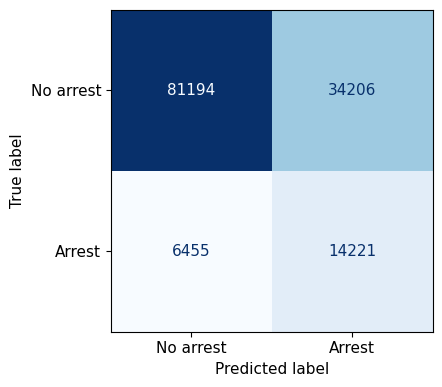

In [5]:
# ارزیابی روی آموزش و آزمون
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, balanced_accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)

def evaluate(model, train_X, train_y, test_X, test_y):
    rows = []
    for name, values, actual in [("Train", train_X, train_y),
                                  ("Test", test_X, test_y)]:
        pred = model.predict(values)
        rec = recall_score(actual, pred, zero_division=0)
        spec = recall_score(actual, pred, pos_label=0, zero_division=0)
        rows.append({"Set": name, "Accuracy": accuracy_score(actual, pred),
                     "Recall": rec, "Specificity": spec,
                     "Precision": precision_score(actual, pred, zero_division=0),
                     "F1": f1_score(actual, pred, zero_division=0),
                     "Balanced accuracy": balanced_accuracy_score(actual, pred),
                     "Youden J": rec + spec - 1})
    return pd.DataFrame(rows).set_index("Set")

display(evaluate(model, A_train[fit_idx], y_train.iloc[fit_idx], A_test, y_test).round(4))
majority = int(y_train.mode().iloc[0])
print("Majority baseline accuracy:", (y_test == majority).mean())
ConfusionMatrixDisplay.from_predictions(
    y_test, model.predict(A_test), labels=[0, 1],
    display_labels=["No arrest", "Arrest"], cmap="Blues", colorbar=False)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## 5. خواندن اثر ویژگی‌ها

نمودار رابطهٔ علّی را نشان نمی‌دهد. در SVM خطی، علامت ضریب جهت اثر بر امتیاز کلاس یک است؛ مقایسهٔ اندازهٔ ضرایب به مقیاس ویژگی‌ها وابسته است.

</div>

,Coefficient
category__Location Description_RESIDENCE,-1.333100
category__Location Description_APARTMENT,-1.333060
category__Primary Type_CRIMINAL DAMAGE,-0.999905
category__Primary Type_THEFT,-0.999879
category__Primary Type_MOTOR VEHICLE THEFT,-0.999788
category__Location Description_STREET,0.666569
category__Location Description_SIDEWALK,0.666626
category__Primary Type_ASSAULT,0.999372
category__Primary Type_BATTERY,1.000030
category__Primary Type_OTHER,1.000170


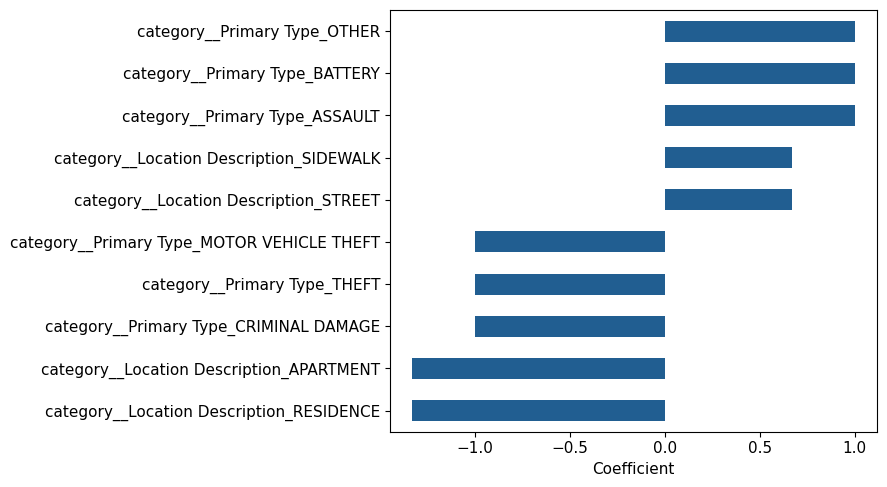

In [6]:
# خواندن اثر ویژگی‌ها
importance = pd.Series(model.coef_.ravel(), index=feature_names)
importance = importance.loc[importance.abs().nlargest(10).index].sort_values()
display(importance.rename("Coefficient").to_frame())
importance.plot.barh(color="#215e91", figsize=(9, 5))
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نکتهٔ پایانی
در این اجرا، مدل همهٔ ردیف‌های آزمون را کلاس صفر پیش‌بینی می‌کند: صحت حدود ۸۴٫۸٪ است، اما Recall و F1 کلاس بازداشت صفر و صحت متوازن ۰٫۵ است. پس صحت بالا در این مثال از فراوانی کلاس اکثریت می‌آید. این نتیجه عملکرد مفید برای یافتن کلاس بازداشت را نشان نمی‌دهد.

</div>

<div dir="rtl" align="right">

## مأخذ مثال
مراجع فنی: [scikit-learn](https://scikit-learn.org/1.8/user_guide.html)، [pandas](https://pandas.pydata.org/docs/)، [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html).

</div>